In [83]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from PIL import Image, ImageOps
import os
import matplotlib.image as mpimg
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neighbors import kneighbors_graph
import networkx as nx
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier as RandomForest

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.utils import class_weight


In [2]:
def process_images_in_folder(folder_path, cell_type, target_size=(64, 64)):
    """
    Converts a folder of images into a pandas DataFrame.

    Args:
        folder_path (str): The path to the folder containing images.
        target_size (tuple): The desired size for each image (width, height).

    Returns:
        pandas.DataFrame: A DataFrame with columns for filename and image data.
    """
    data = []
    
    # Check if the folder exists
    if not os.path.isdir(folder_path):
        print(f"Error: Folder not found at {folder_path}")
        return pd.DataFrame()

    # Iterate over every file in the folder
    for filename in os.listdir(folder_path):
        if filename.endswith(('.png', '.jpg', '.jpeg')):
            file_path = os.path.join(folder_path, filename)
            try:
                # Open the image file
                with Image.open(file_path) as img:
                    # Resize the image and convert it to a NumPy array
                    img_resized = img.resize(target_size)
                    img_array = np.array(img_resized)
                    
                    # Flatten the array to a single row for the DataFrame
                    # This is necessary because DataFrame cells can't easily hold 3D arrays
                    img_array_flat = img_array.flatten()
                    
                    # Store flattened image data
                    data.append({
                        'filename': cell_type,
                        'img_data' : img_array_flat
                    })
            except Exception as e:
                print(f"Skipping file {filename} due to error: {e}")
   
        #Create the pandas DataFrame
    df = pd.DataFrame(data)
    return df
   

In [123]:
# Combine all cell types into one DataFrame
cell_types = [
    'basophil',
    'eosinophil',
    'Ig',
    'lymphocyte',
    'monocyte',
    'neutrophil'
]

all_cells_df = pd.DataFrame()

for cell_type in cell_types:
    folder_path = f"C:\\Users\\goatf\\Documents\\Springboard\\Capstone_3\\Data\\Train_altered\\{cell_type}\\"
    df = process_images_in_folder(folder_path, cell_type)
    all_cells_df = pd.concat([all_cells_df, df], ignore_index=True)

# Now all_cells_df contains all images and their cell type labels
# Example: View the first few rows
# change filename to cell_type
all_cells_df.rename(columns={'filename': 'cell_type'}, inplace=True)
all_cells_df.head()

,cell_type,img_data
0,basophil,"[177, 178, 179, 180, 181, 181, 181, 181, 180, ..."
1,basophil,"[174, 177, 179, 181, 181, 183, 185, 188, 195, ..."
2,basophil,"[229, 223, 241, 238, 215, 234, 249, 216, 239, ..."
3,basophil,"[234, 229, 213, 204, 178, 165, 185, 185, 187, ..."
4,basophil,"[234, 234, 234, 234, 234, 234, 234, 234, 231, ..."


In [4]:
all_cells_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13192 entries, 0 to 13191
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   cell_type  13192 non-null  object
 1   img_data   13192 non-null  object
dtypes: object(2)
memory usage: 206.3+ KB


With this pandas data frame we will try the Knearest neighbor model. The train set will be stratified becasue some photos have different quantities.

In [ ]:
X = np.stack(all_cells_df['img_data'].values)
y = all_cells_df['cell_type']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

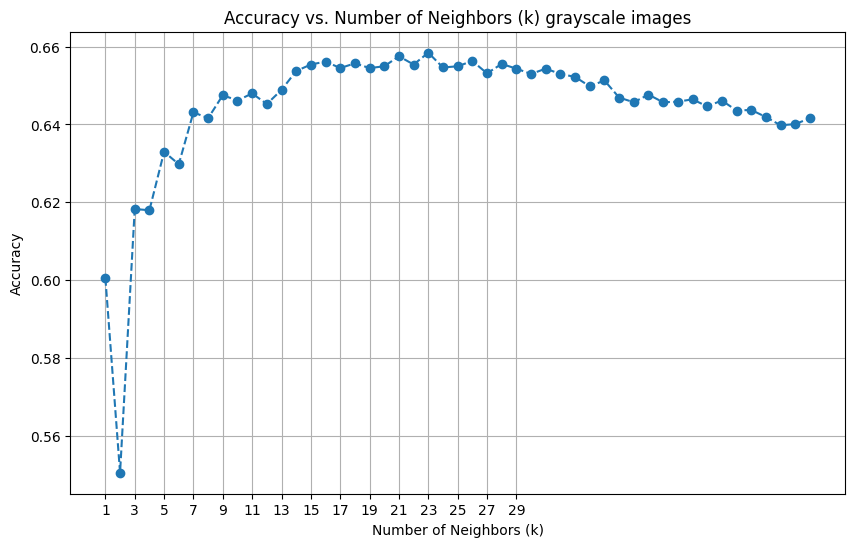

In [6]:
k_values = range(1, 20)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))

plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o', linestyle='--')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. Number of Neighbors (k) grayscale images')
plt.xticks(np.arange(1, 31, 2))
plt.grid(True)
plt.show()

it looks likethe best KNN is between 9 and 14. we will go with 9

In [7]:
# 3. Create and train the nearest neighbor model
# We create a KNeighborsClassifier with a specified number of neighbors
nk=9
knn = KNeighborsClassifier(n_neighbors=nk)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=9)

In [8]:
# evaluating the model with the test set
y_pred = knn.predict(X_test)
print("Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Evaluation:
Accuracy: 0.6475

Classification Report:
              precision    recall  f1-score   support

          Ig       0.48      0.75      0.58      1448
    basophil       0.75      0.22      0.34       609
  eosinophil       0.75      0.74      0.74      1558
  lymphocyte       0.73      0.87      0.79       607
    monocyte       0.45      0.53      0.49       710
  neutrophil       0.96      0.60      0.74      1664

    accuracy                           0.65      6596
   macro avg       0.69      0.62      0.61      6596
weighted avg       0.71      0.65      0.65      6596



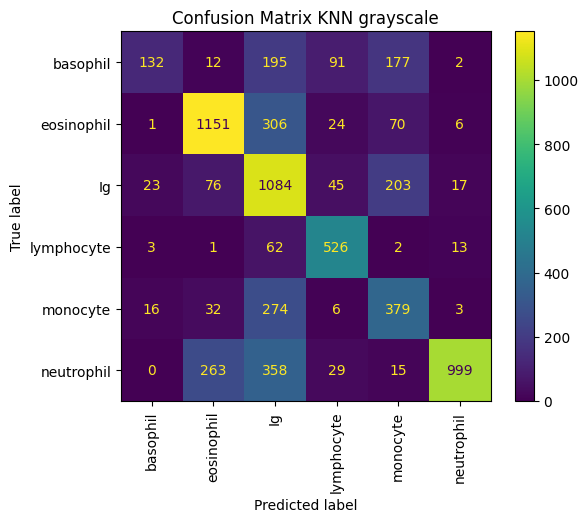

In [9]:
# Get the sorted list of unique labels
class_labels = cell_types
# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=cell_types)
# Create the display object
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)

# Plot the display object
disp.plot(xticks_rotation=90)

# Add a title and show the plot
plt.title('Confusion Matrix KNN grayscale')

plt.show()

In [10]:
# Create the adjacency matrix
knn_adjacency_matrix = kneighbors_graph(X, n_neighbors=nk, mode='connectivity', include_self=False)
# Create a graph object from the adjacency matrix
knn_graph = nx.from_scipy_sparse_array(knn_adjacency_matrix)

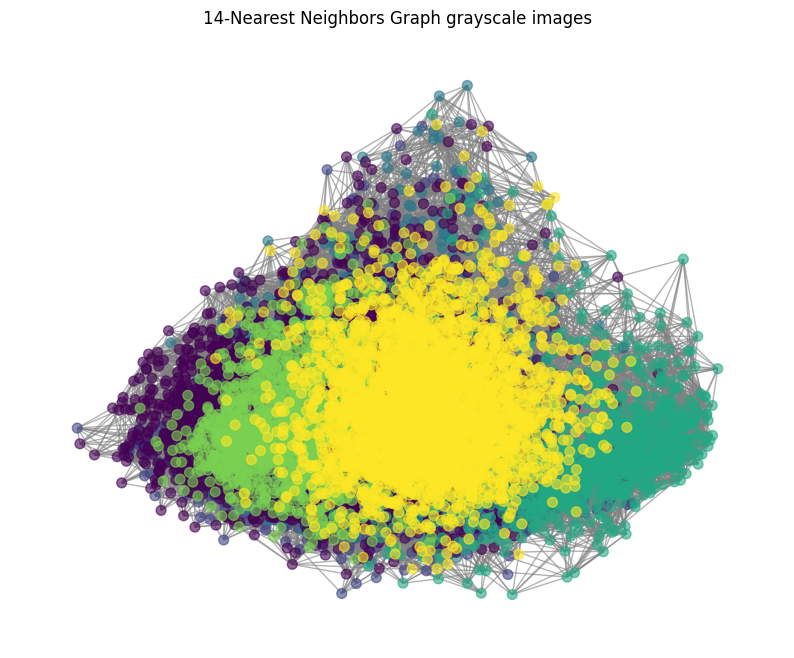

In [11]:
# Reduce X to 2D for plotting
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

plt.figure(figsize=(10, 8))

# Draw the graph using 2D positions
nx.draw_networkx(
    knn_graph,
    pos={i: X_2d[i] for i in range(len(X_2d))},  # Map node index to 2D position
    node_size=50,
    node_color=y.astype('category').cat.codes,  # Convert cell type to integer for coloring
    edge_color='gray',
    alpha=0.6,
    with_labels=False
)

plt.title('14-Nearest Neighbors Graph grayscale images')
plt.axis('off')
plt.show()

Some cell types have better results than others. As we can see from this graph, their are 4 visual areas not 6. This could be possibly be fixed by using colored images instead of black and white.

In [94]:
# Combine all RBG cell types into one DataFrame
# due to size constraints we will use 32x32 images

all_cells_dfRBG = pd.DataFrame()

for cell_type in cell_types:
    folder_path = f"C:\\Users\\goatf\\Documents\\Springboard\\Capstone_3\\Data\\Train_alteredRBG\\{cell_type}\\"
    df = process_images_in_folder(folder_path, cell_type,target_size=(32, 32))
    all_cells_dfRBG = pd.concat([all_cells_dfRBG, df], ignore_index=True)

# Now all_cells_df contains all images and their cell type labels
# Example: View the first few rows
all_cells_dfRBG.rename(columns={'filename': 'cell_type'}, inplace=True)
all_cells_dfRBG.head()

,cell_type,img_data
0,basophil,"[204, 163, 167, 205, 165, 167, 206, 166, 167, ..."
1,basophil,"[206, 168, 129, 208, 163, 177, 208, 166, 185, ..."
2,basophil,"[247, 226, 197, 249, 223, 224, 250, 224, 215, ..."
3,basophil,"[236, 195, 184, 213, 177, 177, 199, 170, 175, ..."
4,basophil,"[255, 230, 198, 255, 230, 200, 255, 229, 203, ..."


In [13]:
all_cells_dfRBG.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13192 entries, 0 to 13191
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   cell_type  13192 non-null  object
 1   img_data   13192 non-null  object
dtypes: object(2)
memory usage: 206.3+ KB


In [100]:
# spliting data to test train again with color image arrays
# staking the image data into a 2D array for model input

X = np.stack(all_cells_dfRBG['img_data'].values)
y = all_cells_dfRBG['cell_type']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

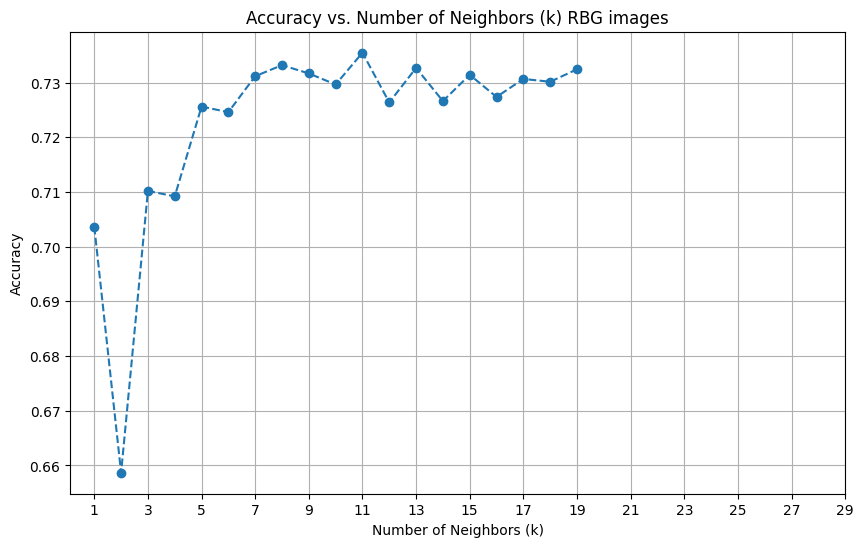

In [15]:
# Finding the best k value again for RBG images
k_values = range(1, 20)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))

plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o', linestyle='--')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. Number of Neighbors (k) RBG images')
plt.xticks(np.arange(1, 31, 2))
plt.grid(True)
plt.show()

It looks like 7 KNN works best

In [16]:
# 3. Create and train the nearest neighbor model
# We create a KNeighborsClassifier with a specified number of neighbors
nk=7
knn = KNeighborsClassifier(n_neighbors=nk)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=7)

In [17]:
# evaluating the model with the test set
y_pred = knn.predict(X_test)
print("Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Evaluation:
Accuracy: 0.7312

Classification Report:
              precision    recall  f1-score   support

          Ig       0.54      0.81      0.65       869
    basophil       0.88      0.21      0.33       365
  eosinophil       0.89      0.86      0.87       935
  lymphocyte       0.77      0.85      0.81       364
    monocyte       0.56      0.72      0.63       426
  neutrophil       0.96      0.70      0.81       999

    accuracy                           0.73      3958
   macro avg       0.77      0.69      0.68      3958
weighted avg       0.78      0.73      0.73      3958



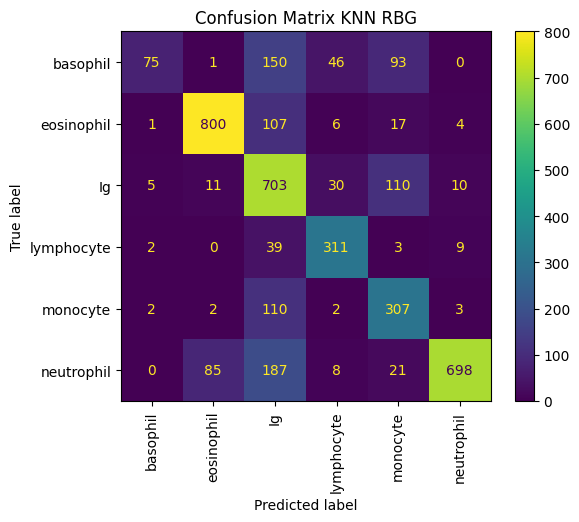

In [18]:
# Get the sorted list of unique labels
class_labels = cell_types
# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=cell_types)
# Create the display object
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)

# Plot the display object
disp.plot(xticks_rotation=90)

# Add a title and show the plot
plt.title('Confusion Matrix KNN RBG')

plt.show()

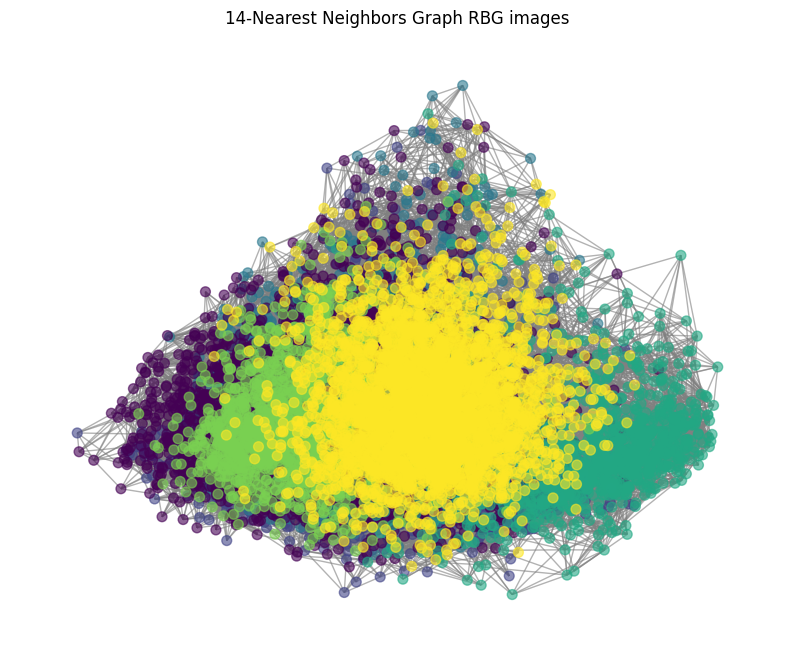

In [19]:
# Create the adjacency matrix
knn_adjacency_matrix = kneighbors_graph(X, n_neighbors=nk, mode='connectivity', include_self=False)
# Create a graph object from the adjacency matrix
knn_graph = nx.from_scipy_sparse_array(knn_adjacency_matrix)

# Reduce X to 2D for plotting
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

plt.figure(figsize=(10, 8))

# Draw the graph using 2D positions
nx.draw_networkx(
    knn_graph,
    pos={i: X_2d[i] for i in range(len(X_2d))},  # Map node index to 2D position
    node_size=50,
    node_color=y.astype('category').cat.codes,  # Convert cell type to integer for coloring
    edge_color='gray',
    alpha=0.6,
    with_labels=False
)

plt.title('14-Nearest Neighbors Graph RBG images')
plt.axis('off')
plt.show()

The RBG gives us better results than plain grayscale images. However it still has the same modeling issues with cell types and the KNN graph looks basically identical.

Next We will try random forest modeling with the RBG images.

In [101]:
# Trying a different model - Random Forest Classifier
rf = RandomForest(random_state=42)
rf.fit(X_train, y_train)
# evaluating the model with the test set
y_pred = rf.predict(X_test)
print("Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Evaluation:
Accuracy: 0.8082

Classification Report:
              precision    recall  f1-score   support

          Ig       0.61      0.83      0.70       869
    basophil       0.81      0.43      0.56       365
  eosinophil       0.94      0.95      0.95       935
  lymphocyte       0.88      0.82      0.85       364
    monocyte       0.86      0.42      0.57       426
  neutrophil       0.88      0.95      0.91       999

    accuracy                           0.81      3958
   macro avg       0.83      0.74      0.76      3958
weighted avg       0.83      0.81      0.80      3958



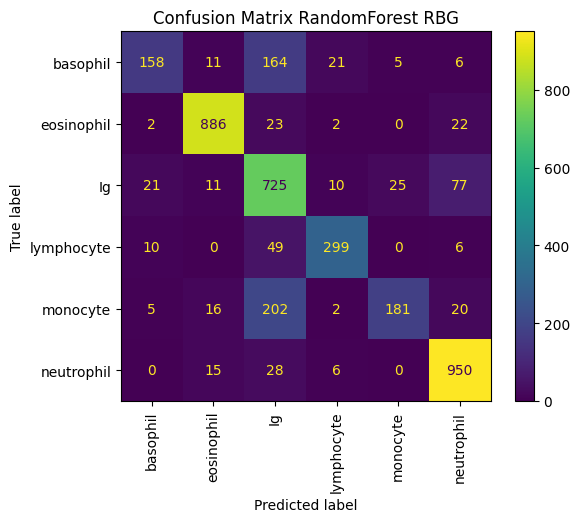

In [102]:
# Get the sorted list of unique labels
class_labels = cell_types
# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=cell_types)
# Create the display object
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)

# Plot the display object
disp.plot(xticks_rotation=90)

# Add a title and show the plot
plt.title('Confusion Matrix RandomForest RBG')

plt.show()

Random forest preforms better than KNN. The main issue is classifing Ig cells.

Now we will try using a neuro net with Tensorflow

In [114]:
# spliting data to test train again with color image arrays
# staking the image data into a 2D array for model input
#factorize the cell types to numerical codes for TensorFlow

X = np.stack(all_cells_dfRBG['img_data'].values)
y, cells = pd.factorize(all_cells_dfRBG['cell_type'], sort = True)

# Split the data into training and a temporary set
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Split the temporary set into a validation and test set
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Train data shape: {X_train.shape}")
print(f"Validation data shape: {X_val.shape}")
print(f"Test data shape: {X_test.shape}")

Train data shape: (9234, 3072)
Validation data shape: (1979, 3072)
Test data shape: (1979, 3072)


In [115]:
# this is for labeling the confusion matrix later
cells = list(cells)
print('Unique cell types:', cells)

Unique cell types: ['Ig', 'basophil', 'eosinophil', 'lymphocyte', 'monocyte', 'neutrophil']


In [97]:
# The 'balanced' mode automatically computes weights inversely proportional
# to the class frequencies
class_weights_array = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_val),
    y=y_val
)

# Convert the weights into a dictionary format required by TensorFlow
class_weights = dict(enumerate(class_weights_array))

print("Calculated class weights:", class_weights)

Calculated class weights: {0: np.float64(0.7599846390168971), 1: np.float64(1.802367941712204), 2: np.float64(0.706281227694504), 3: np.float64(1.8122710622710623), 4: np.float64(1.5485133020344288), 5: np.float64(0.6596666666666666)}


In [99]:

# Build the model
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation=layers.LeakyReLU(alpha=0.5)),
    layers.Dropout(0.3),
    layers.Dense(64, activation=layers.LeakyReLU(alpha=0.5)),
    layers.Dropout(0.3),
    layers.Dense(len(np.unique(y_train)), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=50,
    class_weight=class_weights
)

# Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

Epoch 1/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3604 - loss: 148.2166 - val_accuracy: 0.7014 - val_loss: 17.7259
Epoch 2/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4827 - loss: 67.0986 - val_accuracy: 0.6170 - val_loss: 27.8629
Epoch 3/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4962 - loss: 53.2255 - val_accuracy: 0.5670 - val_loss: 21.5306
Epoch 4/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5305 - loss: 36.6877 - val_accuracy: 0.5796 - val_loss: 16.8900
Epoch 5/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5546 - loss: 26.0355 - val_accuracy: 0.7226 - val_loss: 7.2335
Epoch 6/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5827 - loss: 17.7020 - val_accuracy: 0.6594 - val_loss: 7.4092
Epoch 7/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5896 - loss: 14.0264 - val_accuracy: 0.7059 - val_loss: 5.6979
Epoch 8/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6002 - loss: 9.8353 - val_

In [ ]:
# Get the model's predictions (these are probabilities)
y_pred_probabilities = model.predict(X_test)

# Convert probabilities to class labels (0, 1, 2, etc.)
# tf.argmax returns the index of the maximum value along an axis
y_pred_classes = tf.argmax(y_pred_probabilities, axis=1)


print("Sample predictions:", y_pred_classes[:100].numpy())
print("Sample true labels:", y_test[:100])

62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Sample predictions: [5 4 4 5 4 5 3 1 1 5 1 3 2 5 2 3 3 2 5 2 2 1 4 2 5 3 4 2 4 0 2 4 2 0 4 4 5
 4 2 4 2 1 4 2 2 0 4 4 1 3 4 2 2 2 3 1 5 4 4 5 3 5 5 5 2 3 5 5 2 4 1 1 1 5
 4 1 2 2 5 3 5 0 1 4 2 2 4 5 4 4 4 0 2 4 2 5 4 2 2 0]
Sample true labels: [5 4 0 5 4 5 3 1 1 5 1 3 2 5 2 0 2 2 5 2 2 1 0 2 5 0 4 2 0 0 2 4 2 4 4 0 5
 0 2 4 2 1 0 2 2 0 0 0 1 0 0 2 2 2 3 1 5 4 0 2 3 5 4 5 2 3 5 5 2 0 0 0 1 5
 0 0 2 2 5 3 5 3 1 4 2 2 4 5 5 0 0 0 2 4 2 5 1 2 2 0]


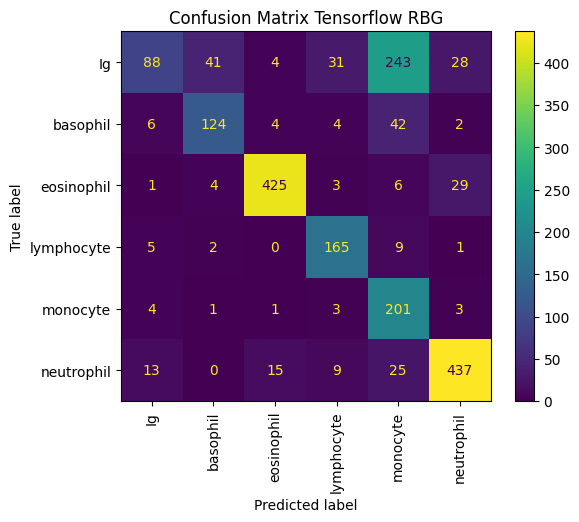

In [ ]:
# Get the sorted list of unique labels
class_labels = cells
# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)
# Create the display object
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)

# Plot the display object
disp.plot(xticks_rotation=90)

# Add a title and show the plot
plt.title('Confusion Matrix Tensorflow RBG')

plt.show()

Using weighted classes the data tensorflow model works fairly well. However, it confuses Monocytes and Ig. If the data set is unweighted it has the opposite affect and classifies to many things as Ig.

Looking at the data Ig look very similar to the monocytes in this data set. Better cell photos should be gathered to better differentiate monocytes and Ig cells.

Next we will compare the tensorflow model and the random forest model using a different data set from kaggle. This data set does not include Ig cells.

In [125]:
# Combine all RBG test cell types into one DataFrame
# due to size constraints we will use 32x32 images

all_cells_testRBG = pd.DataFrame()


for cell_type in cell_types:
    folder_path = f"C:\\Users\\goatf\\Documents\\Springboard\\Capstone_3\\Data\\Test_set\\{cell_type}\\"
    df = process_images_in_folder(folder_path, cell_type,target_size=(32, 32))
    all_cells_testRBG = pd.concat([all_cells_testRBG, df], ignore_index=True)

# Now all_cells_df contains all images and their cell type labels
# Example: View the first few rows
all_cells_testRBG.rename(columns={'filename': 'cell_type'}, inplace=True)
all_cells_testRBG.head()

,cell_type,img_data
0,basophil,"[220, 220, 209, 218, 219, 220, 215, 220, 223, ..."
1,basophil,"[217, 221, 215, 217, 221, 215, 217, 221, 215, ..."
2,basophil,"[226, 220, 221, 223, 221, 214, 221, 225, 209, ..."
3,basophil,"[218, 220, 215, 218, 220, 215, 218, 220, 215, ..."
4,basophil,"[201, 195, 191, 189, 177, 191, 162, 141, 185, ..."


In [126]:
# evaluating the model with the test set for rf
rf_pred = rf.predict(np.stack(all_cells_testRBG['img_data'].values))
print("Model Evaluation:")
print(f"Accuracy: {accuracy_score(all_cells_testRBG['cell_type'], rf_pred):.4f}")
print("\nClassification Report:")
print(classification_report(all_cells_testRBG['cell_type'], rf_pred))

Model Evaluation:
Accuracy: 0.2097

Classification Report:
              precision    recall  f1-score   support

          Ig       0.00      0.00      0.00         0
    basophil       0.00      0.00      0.00       700
  eosinophil       0.00      0.00      0.00       700
  lymphocyte       0.88      0.06      0.11       700
    monocyte       0.00      0.00      0.00       700
  neutrophil       0.21      0.99      0.35       700

    accuracy                           0.21      3500
   macro avg       0.18      0.17      0.08      3500
weighted avg       0.22      0.21      0.09      3500



C:\Users\goatf\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\goatf\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\goatf\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:15

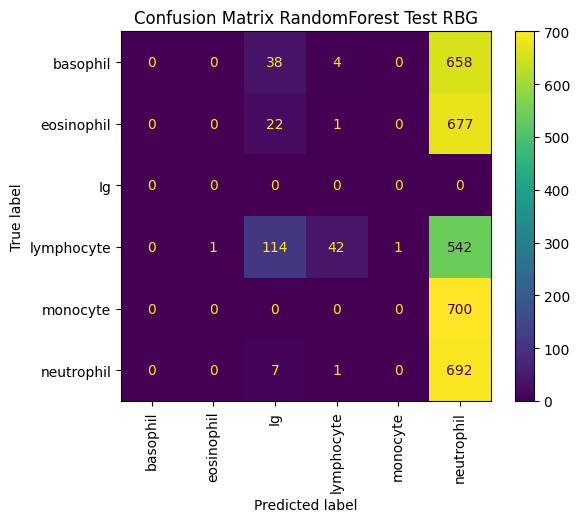

In [127]:
# Get the sorted list of unique labels
class_labels = cell_types
# Compute the confusion matrix
cm = confusion_matrix(all_cells_testRBG['cell_type'], rf_pred, labels=cell_types)
# Create the display object
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)

# Plot the display object
disp.plot(xticks_rotation=90)

# Add a title and show the plot
plt.title('Confusion Matrix RandomForest Test RBG')

plt.show()

In [129]:
#factorize the cell types to numerical codes for TensorFlow
tf_test, lable = pd.factorize(all_cells_testRBG['cell_type'], sort = True)
print(lable)

Index(['basophil', 'eosinophil', 'lymphocyte', 'monocyte', 'neutrophil'], dtype='object')


110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


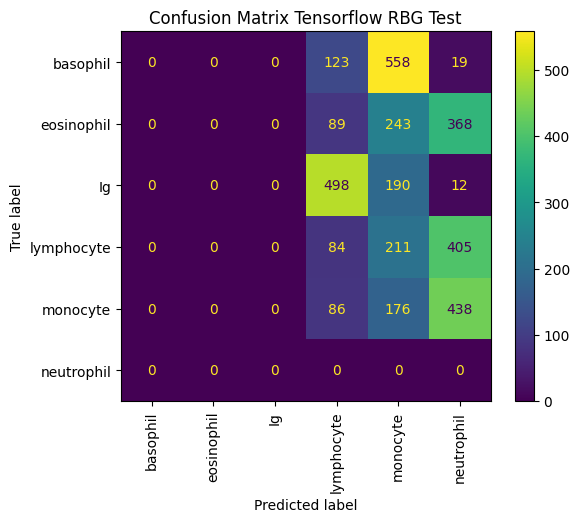

In [133]:
# Get the model's predictions (these are probabilities)
y_pred_test = model.predict(np.stack(all_cells_testRBG['img_data'].values))

# Convert probabilities to class labels (0, 1, 2, etc.)
# tf.argmax returns the index of the maximum value along an axis
y_pred_classes = tf.argmax(y_pred_test, axis=1)



# Compute the confusion matrix
cm = confusion_matrix(tf_test, y_pred_classes)
# Create the display object
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)

# Plot the display object
disp.plot(xticks_rotation=90)

# Add a title and show the plot
plt.title('Confusion Matrix Tensorflow RBG Test')

plt.show()

Both models preform poorly. However, the Tensorflow model does show more robustness and did not catagorize all the images the same. 

The poor preformance is most likely due to the training data set being from one microscope and variaition in cell staining compared to the test data set being from a different microscope and stain.